# 📝 Resumen Ejecutivo: Modelo Baseline VARX (Vector Autoregression)

Este notebook documenta la preparación, entrenamiento y evaluación del modelo estadístico multivariante **VARX** (Vector Autoregression con variables exógenas). Este algoritmo actúa como nuestro **modelo base (baseline)** para establecer las métricas de referencia contra las que competirán los modelos avanzados de Machine Learning (XGBoost) y Deep Learning (LSTM) del proyecto.

### 🛠️ Hitos Metodológicos Alcanzados:

* **Preprocesamiento Estricto:** Se forzó la equidistancia temporal fijando la frecuencia horaria y se solucionaron los huecos de sensórica mediante interpolación lineal (evitando *Data Leakage* al ordenar estrictamente el índice).
* **Prueba de Estacionariedad:** El **Test de Dickey-Fuller Aumentado (ADF)** demostró estadísticamente (p-valor = 0.0000) que las 12 variables endógenas (intensidad, ocupación, velocidad) son estacionarias por la propia naturaleza física acotada del tráfico. Esto nos permitió entrenar el modelo con los datos en crudo sin necesidad de aplicar diferenciación matemática.
* **Ajuste de Dimensionalidad (Lags):** Se evaluaron empíricamente dos ventanas históricas (48h y 168h). Se descartó el modelo VAR(168) tras comprobar que sufría la **Maldición de la Dimensionalidad**: la necesidad de estimar más de 24.000 parámetros provocaba un sobreajuste masivo que colapsaba la capacidad predictiva a futuro (R² medio del 15%). Se designó el **VAR(48)** como el modelo definitivo por su equilibrio entre memoria inercial y robustez matemática.
* **Predicción Multi-Horizonte (1h, 24h, 168h):** Se realizaron las inferencias proyectando dinámicamente el histórico de las variables endógenas y proporcionando el contexto de calendario (variables exógenas deterministas) para las horas futuras a predecir.

### 📊 Conclusiones del Rendimiento:
El modelo VAR(48) demuestra una excelente capacidad para seguir el ciclo circadiano y semanal del tráfico en vías con comportamiento regular (alcanzando métricas de **R² > 0.80** a una semana vista para los sensores 3820 y 6782). No obstante, el desplome de métricas en el **Sensor 6642** (R² negativo) pone en evidencia la principal debilidad de la estadística lineal clásica: su gran vulnerabilidad y ceguera ante anomalías o cortes físicos de la vía, justificando la necesidad técnica de explorar arquitecturas más flexibles en los siguientes notebooks.

# Paso 1: Cargue de csv y preparacion de entorno

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")
 
# Cargue de los csvs
train_df = pd.read_csv('../../data/processed/Split_Datasets/data_train.csv')
val_df = pd.read_csv('../../data/processed/Split_Datasets/data_val.csv')
test_df = pd.read_csv('../../data/processed/Split_Datasets/data_test.csv')

#Creamos funcion para configurar el indice temporal
def preparar_indice_temporal(df):
    """
    Convierte la columna 'fecha' en el índice del DataFrame,
    lo ordena cronológicamente y fuerza una frecuencia horaria ('h').
    """
    # 1. Convertir a formato fecha (datetime)
    df['fecha'] = pd.to_datetime(df['fecha'])
    
    # 2. Establecer como índice
    df.set_index('fecha', inplace=True)
    
    # 3. Ordenar cronologicamente
    df.sort_index(inplace=True)
    
    # 4. Forzar la frecuencia horaria ('h')
    # Esto es OBLIGATORIO para que statsmodels entienda qué es un "lag" (rezago)
    df = df.asfreq('h')    
    
    return df

# Aplicamos la transformacion a los 3 splits
train_df = preparar_indice_temporal(train_df)
val_df = preparar_indice_temporal(val_df)
test_df = preparar_indice_temporal(test_df)

# Separacion VARX: Endogenas (12) y Exogenas
cols_endogenas = [col for col in train_df.columns if 'intensidad' in col or 'ocupacion' in col or 'vmed' in col]

# Variables de calendario (X) - El contexto temporal
cols_exogenas = ['hora', 'dia_semana', 'mes', 'es_finde']

# Mostrar resumen para validar la estructura matemática
print("--- DIMENSIONES Y ESTRUCTURA TEMPORAL ---")
print(f"Train: {train_df.shape} | Inicio: {train_df.index.min()} | Fin: {train_df.index.max()}")
print(f"Val:   {val_df.shape}  | Inicio: {val_df.index.min()} | Fin: {val_df.index.max()}")
print(f"Test:  {test_df.shape}  | Inicio: {test_df.index.min()} | Fin: {test_df.index.max()}\n")

print(f"Total Variables Endógenas ({len(cols_endogenas)}): {cols_endogenas}")
print(f"Total Variables Exógenas  ({len(cols_exogenas)}): {cols_exogenas}")

# Breve chequeo de valores nulos generados por asfreq('H')
nulos_train = train_df[cols_endogenas].isnull().sum().sum()
if nulos_train > 0:
    print(f"\n⚠️ ATENCIÓN: Al forzar la frecuencia horaria, se han detectado {nulos_train} valores nulos en Train.")
else:
    print("\n✅ Datos estructurados correctamente. Cero valores nulos detectados tras fijar la frecuencia.")

# Nulos Val
nulos_val = val_df[cols_endogenas].isnull().sum().sum()
if nulos_val > 0:
    print(f"\n⚠️ ATENCIÓN: Al forzar la frecuencia horaria, se han detectado {nulos_val} valores nulos en Train.")
else:
    print("\n✅ Datos estructurados correctamente. Cero valores nulos detectados tras fijar la frecuencia.")

# Nulos Test
nulos_test = test_df[cols_endogenas].isnull().sum().sum()
if nulos_test > 0:
    print(f"\n⚠️ ATENCIÓN: Al forzar la frecuencia horaria, se han detectado {nulos_test} valores nulos en Train.")
else:
    print("\n✅ Datos estructurados correctamente. Cero valores nulos detectados tras fijar la frecuencia.")


--- DIMENSIONES Y ESTRUCTURA TEMPORAL ---
Train: (16080, 16) | Inicio: 2024-01-01 00:00:00 | Fin: 2025-10-31 23:00:00
Val:   (1464, 16)  | Inicio: 2025-11-01 00:00:00 | Fin: 2025-12-31 23:00:00
Test:  (1416, 16)  | Inicio: 2026-01-01 00:00:00 | Fin: 2026-02-28 23:00:00

Total Variables Endógenas (12): ['intensidad_3820', 'intensidad_6642', 'intensidad_6676', 'intensidad_6782', 'ocupacion_3820', 'ocupacion_6642', 'ocupacion_6676', 'ocupacion_6782', 'vmed_3820', 'vmed_6642', 'vmed_6676', 'vmed_6782']
Total Variables Exógenas  (4): ['hora', 'dia_semana', 'mes', 'es_finde']

⚠️ ATENCIÓN: Al forzar la frecuencia horaria, se han detectado 795 valores nulos en Train.

⚠️ ATENCIÓN: Al forzar la frecuencia horaria, se han detectado 108 valores nulos en Train.

⚠️ ATENCIÓN: Al forzar la frecuencia horaria, se han detectado 21 valores nulos en Train.


C:\Users\cromi\AppData\Local\Temp\ipykernel_27948\1266690966.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


# Paso 1.1: Imputacion adicional de valores nulos
Se imputa un 5 % de los datos que tienen valores nulos, usando interpolacion lineal

In [2]:
# Definimos funcion para hacer imputacion de valores nulos

def limpiar_nulos_series(df, cols_endo):
    # 1. Imputacion de las variables fisicas (Endogenas) mediante Interpolacion Lineal
    # Usamos limit_direction='both' por si el nulo esta en la primera o ultima fila
    df[cols_endo] = df[cols_endo].interpolate(method='linear', limit_direction='both')
    
    # 2. Reconstruccion matematica de las variables de calendario (Exogenas)
    # Extraemos la verdad absoluta desde el indice temporal (DatetimeIndex)
    df['hora'] = df.index.hour
    df['dia_semana'] = df.index.dayofweek
    df['mes'] = df.index.month
    df['es_finde'] = (df['dia_semana'] >= 5).astype(int)
    
    return df

# Aplicamos la limpieza a los tres datasets
train_df = limpiar_nulos_series(train_df, cols_endogenas)
val_df = limpiar_nulos_series(val_df, cols_endogenas)
test_df = limpiar_nulos_series(test_df, cols_endogenas)

# Verificación final de nulos
nulos_finales = train_df.isnull().sum().sum() + val_df.isnull().sum().sum() + test_df.isnull().sum().sum()

if nulos_finales == 0:
    print("✅ LIMPIEZA COMPLETADA: 0 valores nulos en todos los datasets.")
    print("Las series temporales son continuas y están listas para la econometría matemática.")
else:
    print(f"⚠️ Aún quedan {nulos_finales} nulos.")

✅ LIMPIEZA COMPLETADA: 0 valores nulos en todos los datasets.
Las series temporales son continuas y están listas para la econometría matemática.


# Paso 2: Procesamiento Estadistico

In [3]:
# Paso 2.1: Analisis de Estacionariedad mediante el Test de Dickey-Fuller Aumentado (ADF).
from statsmodels.tsa.stattools import adfuller

def test_estacionariedad(df, columnas):
    print("--- RESULTADOS DEL TEST DE DICKEY-FULLER AUMENTADO (ADF) ---")
    print("Nivel de significancia (alfa): 0.05")
    print("H0: La serie tiene una raíz unitaria (NO es estacionaria)")
    print("H1: La serie es estacionaria (p-valor < 0.05)\n")
    
    no_estacionarias = []
    
    for col in columnas:
        # Ejecutamos el test ADF. 
        # autolag='AIC' le dice a statsmodels que elija los mejores rezagos internamente para el test
        adf_test = adfuller(df[col], autolag='AIC')
        p_value = adf_test[1]
        
        es_estacionaria = p_value < 0.05
        
        if es_estacionaria:
            estado = "✅ Estacionaria"
        else:
            estado = "❌ NO Estacionaria"
            no_estacionarias.append(col)
            
        # Formateamos el print para que quede como una tabla limpia
        print(f"Variable: {col:<20} | p-valor: {p_value:.4f} | {estado}")
        
    return no_estacionarias

# Aplicamos el test EXCLUSIVAMENTE a las 12 variables endógenas del Train
variables_a_diferenciar = test_estacionariedad(train_df, cols_endogenas)

if len(variables_a_diferenciar) == 0:
    print("\n🎉 ¡Grandes noticias! Todas las series son estacionarias por naturaleza. No hace falta diferenciación.")
else:
    print(f"\n⚠️ ATENCIÓN: Hay {len(variables_a_diferenciar)} series NO estacionarias. Necesitaremos aplicar diferenciación.")

--- RESULTADOS DEL TEST DE DICKEY-FULLER AUMENTADO (ADF) ---
Nivel de significancia (alfa): 0.05
H0: La serie tiene una raíz unitaria (NO es estacionaria)
H1: La serie es estacionaria (p-valor < 0.05)

Variable: intensidad_3820      | p-valor: 0.0000 | ✅ Estacionaria
Variable: intensidad_6642      | p-valor: 0.0000 | ✅ Estacionaria
Variable: intensidad_6676      | p-valor: 0.0000 | ✅ Estacionaria
Variable: intensidad_6782      | p-valor: 0.0000 | ✅ Estacionaria
Variable: ocupacion_3820       | p-valor: 0.0000 | ✅ Estacionaria
Variable: ocupacion_6642       | p-valor: 0.0000 | ✅ Estacionaria
Variable: ocupacion_6676       | p-valor: 0.0000 | ✅ Estacionaria
Variable: ocupacion_6782       | p-valor: 0.0000 | ✅ Estacionaria
Variable: vmed_3820            | p-valor: 0.0000 | ✅ Estacionaria
Variable: vmed_6642            | p-valor: 0.0000 | ✅ Estacionaria
Variable: vmed_6676            | p-valor: 0.0000 | ✅ Estacionaria
Variable: vmed_6782            | p-valor: 0.0000 | ✅ Estacionaria

🎉 ¡Gr

# Paso 3 - 4:  Configuración y Forzado de los Rezagos: $p=48$ y $p=168$

In [4]:
from statsmodels.tsa.api import VAR

# 1. Separamos las matrices de entrenamiento
endog_train = train_df[cols_endogenas]
exog_train = train_df[cols_exogenas]

# 2. Instanciamos el modelo VARX
# Le pasamos el motor principal (endog) y el contexto de calendario (exog)
modelo_var = VAR(endog=endog_train, exog=exog_train)

print("--- ENTRENAMIENTO DEL MODELO VARX ---")
print("Dimensiones de la matriz de entrada:")
print(f"Endógenas (Físicas): {endog_train.shape[1]} variables")
print(f"Exógenas (Calendario): {exog_train.shape[1]} variables\n")


# Prueba A: Ventana de 48 horas (Lag p = 48)

try:
    print("⏳ Ajustando VARX con ventana de 48 horas (p=48)... (Puede tardar 1-3 minutos)")
    # El parámetro maxlags fija el tamaño de la ventana. Al no poner 'ic', forzamos que use 48 exactos.
    var_48 = modelo_var.fit(maxlags=48, trend='c')
    print("✅ ¡ÉXITO! Modelo VAR(48) entrenado correctamente.")
    print(f"-> Parámetros estimados por cada ecuación: {var_48.df_model}")
except Exception as e:
    print(f"❌ ERROR al ajustar p=48. Detalle: {e}")


# Prueba B: Ventana de 168 horas (Lag p = 168)
try:
    print("\n⏳ Ajustando VARX con ventana de 1 semana (p=168)... (¡Atención: Riesgo de colapso de RAM/Álgebra Lineal!)")
    var_168 = modelo_var.fit(maxlags=168, trend='c')
    print("✅Modelo VAR(168) entrenado correctamente.")
    print(f"-> Parametros estimados por cada ecuación: {var_168.df_model}")
except Exception as e:
    print(f"❌ ERROR MATEMÁTICO al ajustar p=168 (Esperado por la Maldición de la Dimensionalidad).")
    print(f"-> El VAR no soporta calcular tantas interacciones. Detalle técnico: {e}")
    print("-> Justificación para el TFM: Se utilizará el modelo de 48 horas como baseline estadístico definitivo.")

--- ENTRENAMIENTO DEL MODELO VARX ---
Dimensiones de la matriz de entrada:
Endógenas (Físicas): 12 variables
Exógenas (Calendario): 4 variables

⏳ Ajustando VARX con ventana de 48 horas (p=48)... (Puede tardar 1-3 minutos)
✅ ¡ÉXITO! Modelo VAR(48) entrenado correctamente.
-> Parámetros estimados por cada ecuación: 581

⏳ Ajustando VARX con ventana de 1 semana (p=168)... (¡Atención: Riesgo de colapso de RAM/Álgebra Lineal!)
✅Modelo VAR(168) entrenado correctamente.
-> Parametros estimados por cada ecuación: 2021


# Paso 5: Prediccion Multi-horizonte.


## Prediccion con ventana(lag) de 48 horas

In [5]:
import pandas as pd

print("--- INICIANDO FORECASTING MULTI-HORIZONTE (VAR-48) ---")

# Tomamos las ultimas 48 horas de Train (Y_hist)
y_hist = train_df[cols_endogenas].values[-48:]

# Extraemos las variables exogenas de Validacion
# Tomamos las primeras 168 horas de val_df porque es nuestro horizonte maximo
exog_val_future = val_df[cols_exogenas].iloc[:168].values
# Fechas futuras
indices_futuros = val_df.index[:168]

# Prediccion a Corto Plazo (1 hora) ---
# Le pasamos el trampolin (y), los pasos (steps) y el calendario futuro de esa hora
pred_1 = var_48.forecast(y=y_hist, steps=1, exog_future=exog_val_future[:1])
df_pred_48_1 = pd.DataFrame(pred_1, index=indices_futuros[:1], columns=cols_endogenas)
print("✅ Predicción a 1 hora (1 step) completada.")

# Predicción a Medio Plazo (24 horas) ---
pred_24 = var_48.forecast(y=y_hist, steps=24, exog_future=exog_val_future[:24])
df_pred_48_24 = pd.DataFrame(pred_24, index=indices_futuros[:24], columns=cols_endogenas)
print("✅ Predicción a 24 horas (24 steps) completada.")

# Predicción a Largo Plazo (168 horas / 1 semana) ---
pred_168 = var_48.forecast(y=y_hist, steps=168, exog_future=exog_val_future[:168])
df_pred_48_168 = pd.DataFrame(pred_168, index=indices_futuros[:168], columns=cols_endogenas)
print("✅ Predicción a 168 horas (1 semana) completada.\n")

# Mostramos un vistazo a los resultados de la primera variable (Intensidad 3820)
print("--- VISTAZO A LAS PREDICCIONES (Intensidad Sensor 3820) ---")
df_muestra = pd.DataFrame({
    'Real (val_df)': val_df['intensidad_3820'].iloc[:5],
    'Predicción VAR(48)': df_pred_48_168['intensidad_3820'].iloc[:5]
})
print(df_muestra)

--- INICIANDO FORECASTING MULTI-HORIZONTE (VAR-48) ---
✅ Predicción a 1 hora (1 step) completada.
✅ Predicción a 24 horas (24 steps) completada.
✅ Predicción a 168 horas (1 semana) completada.

--- VISTAZO A LAS PREDICCIONES (Intensidad Sensor 3820) ---
                     Real (val_df)  Predicción VAR(48)
fecha                                                 
2025-11-01 00:00:00        2463.50         2475.685553
2025-11-01 01:00:00        1573.50         1898.293626
2025-11-01 02:00:00        1107.00         1517.092023
2025-11-01 03:00:00         859.25         1062.979737
2025-11-01 04:00:00         810.25          726.427603


## Prediccion con ventana(lag) de 168 horas

In [6]:
import pandas as pd

print("--- INICIANDO FORECASTING MULTI-HORIZONTE (VAR-48) ---")

# Tomamos las ultimas 168 horas de Train (Y_hist)
y_hist = train_df[cols_endogenas].values[-168:]

# Extraemos las variables exogenas de Validacion
# Tomamos las primeras 168 horas de val_df porque es nuestro horizonte maximo
exog_val_future = val_df[cols_exogenas].iloc[:168].values
# Fechas futuras
indices_futuros = val_df.index[:168]

# Prediccion a Corto Plazo (1 hora) ---
# Le pasamos el trampolin (y), los pasos (steps) y el calendario futuro de esa hora
pred_1 = var_168.forecast(y=y_hist, steps=1, exog_future=exog_val_future[:1])
df_pred_168_1 = pd.DataFrame(pred_1, index=indices_futuros[:1], columns=cols_endogenas)
print("✅ Predicción a 1 hora (1 step) completada.")

# Predicción a Medio Plazo (24 horas) ---
pred_24 = var_168.forecast(y=y_hist, steps=24, exog_future=exog_val_future[:24])
df_pred_168_24 = pd.DataFrame(pred_24, index=indices_futuros[:24], columns=cols_endogenas)
print("✅ Predicción a 24 horas (24 steps) completada.")

# Predicción a Largo Plazo (168 horas / 1 semana) ---
pred_168 = var_168.forecast(y=y_hist, steps=168, exog_future=exog_val_future[:168])
df_pred_168_168 = pd.DataFrame(pred_168, index=indices_futuros[:168], columns=cols_endogenas)
print("✅ Predicción a 168 horas (1 semana) completada.\n")

# Mostramos un vistazo a los resultados de la primera variable (Intensidad 3820)
print("--- VISTAZO A LAS PREDICCIONES (Intensidad Sensor 3820) ---")
df_muestra = pd.DataFrame({
    'Real (val_df)': val_df['intensidad_3820'].iloc[:5],
    'Predicción VAR(48)': df_pred_168_168['intensidad_3820'].iloc[:5]
})
print(df_muestra)

--- INICIANDO FORECASTING MULTI-HORIZONTE (VAR-48) ---
✅ Predicción a 1 hora (1 step) completada.
✅ Predicción a 24 horas (24 steps) completada.
✅ Predicción a 168 horas (1 semana) completada.

--- VISTAZO A LAS PREDICCIONES (Intensidad Sensor 3820) ---
                     Real (val_df)  Predicción VAR(48)
fecha                                                 
2025-11-01 00:00:00        2463.50         2814.354147
2025-11-01 01:00:00        1573.50         2063.339081
2025-11-01 02:00:00        1107.00         1592.860315
2025-11-01 03:00:00         859.25         1029.894445
2025-11-01 04:00:00         810.25          626.349097


# Paso 6: Evaluacion Errores RMSE - R^2

## Evaluacion con ventana(lag) de 48 horas

In [7]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

print("--- EVALUACIÓN DE RENDIMIENTO (Solo variables de Intensidad) ---")

# Filtramos solo las columnas objetivo (los 4 sensores de intensidad)
cols_intensidad = [col for col in cols_endogenas if 'intensidad' in col]

def evaluar_predicciones(df_real, df_pred, horizonte_texto):
    print(f"\n[ HORIZONTE: {horizonte_texto} ]")
    rmse_list = []
    r2_list = []
    
    for col in cols_intensidad:
        # Alineamos los datos reales con la longitud de la predicción (1, 24 o 168)
        real = df_real[col].iloc[:len(df_pred)]
        pred = df_pred[col]
        
        # Cálculo de métricas
        rmse = np.sqrt(mean_squared_error(real, pred))
        r2 = r2_score(real, pred)
        
        rmse_list.append(rmse)
        r2_list.append(r2)
        
        print(f"Sensor {col[-4:]} -> RMSE: {rmse:>7.2f} veh/h | R²: {r2:>7.4f}")
        
    print("-" * 50)
    print(f">> PROMEDIO GLOBAL {horizonte_texto[:7]} -> RMSE: {np.mean(rmse_list):.2f} veh/h | R²: {np.mean(r2_list):.4f}")

# Evaluamos los 3 horizontes usando nuestro baseline VAR(48)
evaluar_predicciones(val_df, df_pred_48_1, "1 HORA (Corto Plazo)")
evaluar_predicciones(val_df, df_pred_48_24, "24 HORAS (Medio Plazo)")
evaluar_predicciones(val_df, df_pred_48_168, "168 HORAS (1 Semana)")

--- EVALUACIÓN DE RENDIMIENTO (Solo variables de Intensidad) ---

[ HORIZONTE: 1 HORA (Corto Plazo) ]
Sensor 3820 -> RMSE:   12.19 veh/h | R²:     nan
Sensor 6642 -> RMSE:  473.06 veh/h | R²:     nan
Sensor 6676 -> RMSE:  108.39 veh/h | R²:     nan
Sensor 6782 -> RMSE:  412.18 veh/h | R²:     nan
--------------------------------------------------
>> PROMEDIO GLOBAL 1 HORA  -> RMSE: 251.46 veh/h | R²: nan

[ HORIZONTE: 24 HORAS (Medio Plazo) ]
Sensor 3820 -> RMSE:  832.15 veh/h | R²:  0.5757
Sensor 6642 -> RMSE: 2201.26 veh/h | R²: -3.0462
Sensor 6676 -> RMSE: 1155.07 veh/h | R²:  0.6021
Sensor 6782 -> RMSE:  625.32 veh/h | R²:  0.7159
--------------------------------------------------
>> PROMEDIO GLOBAL 24 HORA -> RMSE: 1203.45 veh/h | R²: -0.2881

[ HORIZONTE: 168 HORAS (1 Semana) ]
Sensor 3820 -> RMSE:  711.86 veh/h | R²:  0.8570
Sensor 6642 -> RMSE: 2275.29 veh/h | R²: -0.4584
Sensor 6676 -> RMSE: 1188.46 veh/h | R²:  0.6606
Sensor 6782 -> RMSE:  759.96 veh/h | R²:  0.8162
---------

## Evaluacion con ventana(lag) de 168 horas

In [10]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

print("--- EVALUACIÓN DE RENDIMIENTO (Solo variables de Intensidad) ---")

# Filtramos solo las columnas objetivo (los 4 sensores de intensidad)
cols_intensidad = [col for col in cols_endogenas if 'intensidad' in col]

def evaluar_predicciones(df_real, df_pred, horizonte_texto):
    print(f"\n[ HORIZONTE: {horizonte_texto} ]")
    rmse_list = []
    r2_list = []
    
    for col in cols_intensidad:
        # Alineamos los datos reales con la longitud de la predicción (1, 24 o 168)
        real = df_real[col].iloc[:len(df_pred)]
        pred = df_pred[col]
        
        # Cálculo de métricas
        rmse = np.sqrt(mean_squared_error(real, pred))
        r2 = r2_score(real, pred)
        
        rmse_list.append(rmse)
        r2_list.append(r2)
        
        print(f"Sensor {col[-4:]} -> RMSE: {rmse:>7.2f} veh/h | R²: {r2:>7.4f}")
        
    print("-" * 50)
    print(f">> PROMEDIO GLOBAL {horizonte_texto[:7]} -> RMSE: {np.mean(rmse_list):.2f} veh/h | R²: {np.mean(r2_list):.4f}")

# Evaluamos los 3 horizontes usando nuestro baseline VAR(168)
evaluar_predicciones(val_df, df_pred_168_1, "1 HORA (Corto Plazo)")
evaluar_predicciones(val_df, df_pred_168_24, "24 HORAS (Medio Plazo)")
evaluar_predicciones(val_df, df_pred_168_168, "168 HORAS (1 Semana)")

--- EVALUACIÓN DE RENDIMIENTO (Solo variables de Intensidad) ---

[ HORIZONTE: 1 HORA (Corto Plazo) ]
Sensor 3820 -> RMSE:  350.85 veh/h | R²:     nan
Sensor 6642 -> RMSE:  538.18 veh/h | R²:     nan
Sensor 6676 -> RMSE:  294.25 veh/h | R²:     nan
Sensor 6782 -> RMSE:   53.66 veh/h | R²:     nan
--------------------------------------------------
>> PROMEDIO GLOBAL 1 HORA  -> RMSE: 309.24 veh/h | R²: nan

[ HORIZONTE: 24 HORAS (Medio Plazo) ]
Sensor 3820 -> RMSE:  723.08 veh/h | R²:  0.6797
Sensor 6642 -> RMSE: 2329.81 veh/h | R²: -3.5326
Sensor 6676 -> RMSE: 1212.02 veh/h | R²:  0.5619
Sensor 6782 -> RMSE:  557.51 veh/h | R²:  0.7741
--------------------------------------------------
>> PROMEDIO GLOBAL 24 HORA -> RMSE: 1205.61 veh/h | R²: -0.3792

[ HORIZONTE: 168 HORAS (1 Semana) ]
Sensor 3820 -> RMSE:  579.85 veh/h | R²:  0.9051
Sensor 6642 -> RMSE: 3135.81 veh/h | R²: -1.7701
Sensor 6676 -> RMSE: 1260.18 veh/h | R²:  0.6184
Sensor 6782 -> RMSE:  683.10 veh/h | R²:  0.8515
---------

# Paso 7: Visualizacion de los resultados 

--- GENERANDO GRÁFICOS DE ALTA RESOLUCIÓN ---


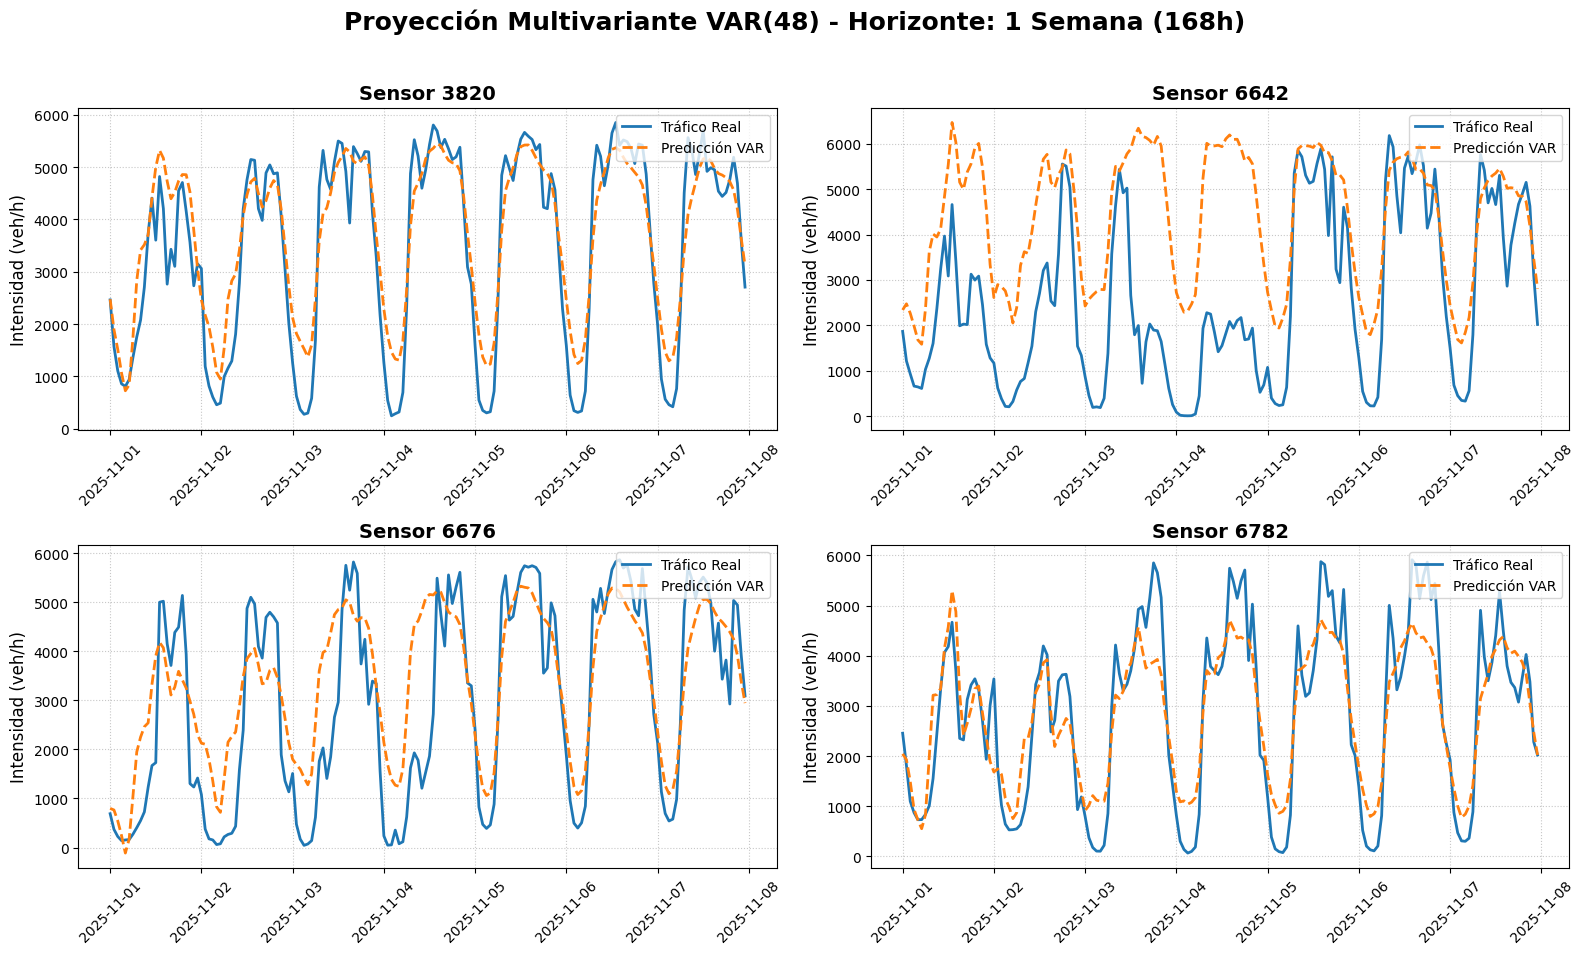

In [12]:
import matplotlib.pyplot as plt

print("--- GENERANDO GRÁFICOS DE ALTA RESOLUCIÓN ---")

# Configuramos el estilo del gráfico (limpio y académico)
plt.style.use('default')
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 10))
fig.suptitle('Proyección Multivariante VAR(48) - Horizonte: 1 Semana (168h)', fontsize=18, fontweight='bold', y=0.95)

# Aplanamos la matriz de ejes para iterar fácilmente con un bucle
axes = axes.flatten()

# Iteramos sobre los 4 sensores de intensidad
for i, col in enumerate(cols_intensidad):
    ax = axes[i]
    
    # Extraemos el número del sensor para el título
    sensor_id = col.split('_')[1]
    
    # Extraemos los datos a dibujar
    real_data = val_df[col].iloc[:168]
    pred_data = df_pred_48_168[col]
    
    # Dibujamos las líneas
    ax.plot(real_data.index, real_data.values, label='Tráfico Real', color='#1f77b4', linewidth=2)
    ax.plot(pred_data.index, pred_data.values, label='Predicción VAR', color='#ff7f0e', linestyle='--', linewidth=2)
    
    # Personalización del sub-gráfico
    ax.set_title(f'Sensor {sensor_id}', fontsize=14, fontweight='bold')
    ax.set_ylabel('Intensidad (veh/h)', fontsize=12)
    ax.grid(True, linestyle=':', alpha=0.7)
    ax.legend(loc='upper right')
    
    # Rotamos las fechas para que se lean bien
    ax.tick_params(axis='x', rotation=45)

# Ajustamos el espaciado para que no se solapen los textos
plt.tight_layout(rect=[0, 0, 1, 0.93])

plt.show()

--- GENERANDO GRÁFICOS DE ALTA RESOLUCIÓN ---


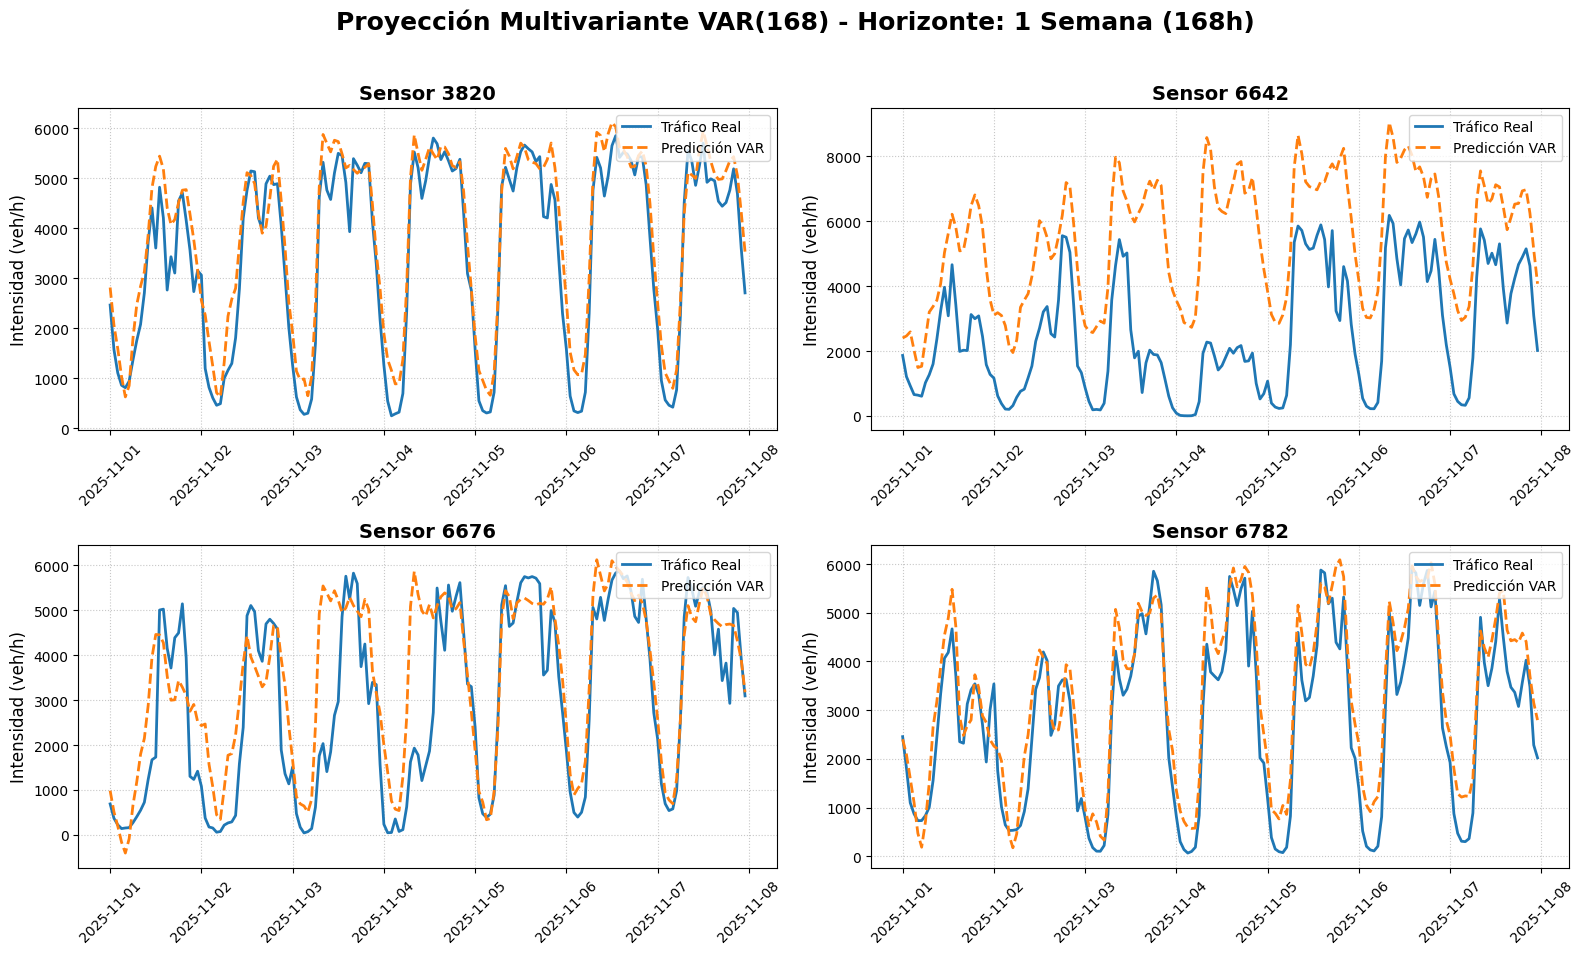

In [13]:
import matplotlib.pyplot as plt

print("--- GENERANDO GRÁFICOS DE ALTA RESOLUCIÓN ---")

# Configuramos el estilo del gráfico (limpio y académico)
plt.style.use('default')
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 10))
fig.suptitle('Proyección Multivariante VAR(168) - Horizonte: 1 Semana (168h)', fontsize=18, fontweight='bold', y=0.95)

# Aplanamos la matriz de ejes para iterar fácilmente con un bucle
axes = axes.flatten()

# Iteramos sobre los 4 sensores de intensidad
for i, col in enumerate(cols_intensidad):
    ax = axes[i]
    
    # Extraemos el número del sensor para el título
    sensor_id = col.split('_')[1]
    
    # Extraemos los datos a dibujar
    real_data = val_df[col].iloc[:168]
    pred_data = df_pred_168_168[col]
    
    # Dibujamos las líneas
    ax.plot(real_data.index, real_data.values, label='Tráfico Real', color='#1f77b4', linewidth=2)
    ax.plot(pred_data.index, pred_data.values, label='Predicción VAR', color='#ff7f0e', linestyle='--', linewidth=2)
    
    # Personalización del sub-gráfico
    ax.set_title(f'Sensor {sensor_id}', fontsize=14, fontweight='bold')
    ax.set_ylabel('Intensidad (veh/h)', fontsize=12)
    ax.grid(True, linestyle=':', alpha=0.7)
    ax.legend(loc='upper right')
    
    # Rotamos las fechas para que se lean bien
    ax.tick_params(axis='x', rotation=45)

# Ajustamos el espaciado para que no se solapen los textos
plt.tight_layout(rect=[0, 0, 1, 0.93])

plt.show()

In [14]:
# ==========================================
# EXPORTACIÓN DE DATOS LIMPIOS PARA OTROS MODELOS
# ==========================================

print("--- GUARDANDO DATASETS LIMPIOS EN DISCO ---")

# Exportamos manteniendo el índice temporal
train_df.to_csv('../../data/processed/Split_Datasets/data_train_clean.csv')
val_df.to_csv('../../data/processed/Split_Datasets/data_val_clean.csv')
test_df.to_csv('../../data/processed/Split_Datasets/data_test_clean.csv')

print("✅ ¡Éxito! Archivos 'data_train_clean.csv', 'data_val_clean.csv' y 'data_test_clean.csv' generados.")
print("Ahora cualquier otro notebook puede cargarlos directamente sin tener que limpiar nulos.")

--- GUARDANDO DATASETS LIMPIOS EN DISCO ---
✅ ¡Éxito! Archivos 'data_train_clean.csv', 'data_val_clean.csv' y 'data_test_clean.csv' generados.
Ahora cualquier otro notebook puede cargarlos directamente sin tener que limpiar nulos.
